# 03 — Treinamento da Rede Neural Multi-alvo  
**OscaBet Agent** · 3 cabeças: Resultado · Cartões · Escanteios

Arquitetura conforme §11 do plano:  
`Dense(256)→Dense(128)→Dense(64)` + 3× `Softmax(3)` com corte temporal.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import log_loss, accuracy_score
from sklearn.calibration import calibration_curve
from pathlib import Path
import warnings, json

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

# ──────────────────────────────────────────────────────────────────────────────
# SWAP: altere BASE_DIR para o caminho do projeto no seu computador
# ──────────────────────────────────────────────────────────────────────────────
BASE_DIR   = Path("../..").resolve()
PROC_DIR   = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "agent" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Hiperparâmetros (espelham .env do projeto) ────────────────────────────────
TRAIN_CUTOFF_DATE = "2023-06-30"
BATCH_SIZE        = 256
LR                = 1e-3
WEIGHT_DECAY      = 1e-4
EPOCHS            = 80
EARLY_STOP_PAT    = 20
LR_PATIENCE       = 10
LOSS_W_RESULT     = 1.0
LOSS_W_YELLOW     = 0.8
LOSS_W_CORNERS    = 0.8
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
print(f"Corte temporal: {TRAIN_CUTOFF_DATE}")


Device: cpu
Corte temporal: 2023-06-30


## 1. Carregamento e Split Temporal

In [25]:
features = pd.read_csv(PROC_DIR / "features.csv", parse_dates=["date"])
targets  = pd.read_csv(PROC_DIR / "targets.csv",  parse_dates=["match_date"])

assert len(features) == len(targets), "Tamanhos inconsistentes!"

# Colunas de input (excluir metadados)
META_COLS  = ["match_id","date","league","season","home_team","away_team"]
TARGET_COLS= ["match_id","match_date","league","result","yellow_cat","corners_cat"]
feat_cols  = [c for c in features.columns if c not in META_COLS
              and features[c].dtype in (float, np.float64, np.float32, int, np.int64)]

# Remover colunas com NaN > 30%
nan_pct = features[feat_cols].isnull().mean()
feat_cols = [c for c in feat_cols if nan_pct[c] < 0.30]
print(f"Features selecionadas: {len(feat_cols)}")

# Preencher NaN restantes com mediana
X = features[feat_cols].fillna(features[feat_cols].median())

# Split temporal
cutoff     = pd.to_datetime(TRAIN_CUTOFF_DATE)
train_mask = features["date"] <  cutoff
val_mask   = features["date"] >= cutoff

X_train, X_val = X[train_mask].values, X[val_mask].values
y_result_train  = targets.loc[train_mask, "result"].fillna(-1).astype(int).values
y_result_val    = targets.loc[val_mask,   "result"].fillna(-1).astype(int).values
y_yellow_train  = targets.loc[train_mask, "yellow_cat"].fillna(-1).astype(int).values
y_yellow_val    = targets.loc[val_mask,   "yellow_cat"].fillna(-1).astype(int).values
y_corn_train    = targets.loc[train_mask, "corners_cat"].fillna(-1).astype(int).values
y_corn_val      = targets.loc[val_mask,   "corners_cat"].fillna(-1).astype(int).values

# Remove amostras com target inválido (NaN virou -1)
valid_train = (y_result_train >= 0) & (y_yellow_train >= 0) & (y_corn_train >= 0)
valid_val   = (y_result_val   >= 0) & (y_yellow_val   >= 0) & (y_corn_val   >= 0)

X_train, y_result_train, y_yellow_train, y_corn_train = (
    X_train[valid_train], y_result_train[valid_train],
    y_yellow_train[valid_train], y_corn_train[valid_train]
)
X_val, y_result_val, y_yellow_val, y_corn_val = (
    X_val[valid_val], y_result_val[valid_val],
    y_yellow_val[valid_val], y_corn_val[valid_val]
)

print(f"Treino  : {len(X_train):,} partidas  |  Features: {X_train.shape[1]}")
print(f"Validação: {len(X_val):,} partidas")
print()
for name, arr in [("result_train",y_result_train),("yellow_train",y_yellow_train),("corners_train",y_corn_train)]:
    vals, cnts = np.unique(arr, return_counts=True)
    print(f"  {name}: " + "  ".join(f"cls{v}={c/len(arr)*100:.1f}%" for v, c in zip(vals, cnts)))


Features selecionadas: 71
Treino  : 3,303 partidas  |  Features: 71
Validação: 2,171 partidas

  result_train: cls0=43.5%  cls1=26.6%  cls2=29.9%
  yellow_train: cls0=77.7%  cls1=22.3%
  corners_train: cls0=60.3%  cls1=39.7%


## 2. Dataset PyTorch

In [26]:
class MatchDataset(Dataset):
    def __init__(self, X, y_result, y_yellow, y_corners):
        self.X         = torch.tensor(X, dtype=torch.float32)
        self.y_result  = torch.tensor(y_result,  dtype=torch.long)
        self.y_yellow  = torch.tensor(y_yellow,  dtype=torch.long)
        self.y_corners = torch.tensor(y_corners, dtype=torch.long)

    def __len__(self):  return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_result[idx], self.y_yellow[idx], self.y_corners[idx]

train_ds = MatchDataset(X_train, y_result_train, y_yellow_train, y_corn_train)
val_ds   = MatchDataset(X_val,   y_result_val,   y_yellow_val,   y_corn_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches treino: {len(train_loader)}  |  Batches val: {len(val_loader)}")


Batches treino: 12  |  Batches val: 9


## 3. Arquitetura — OscaBetNN (Multi-task, 3 Cabeças)

In [27]:
class OscaBetNN(nn.Module):
    """
    Rede neural multi-alvo conforme §11 do plano.

    Backbone compartilhado:
        Dense(256, ReLU) + BN + Dropout(0.3)
        Dense(128, ReLU) + BN + Dropout(0.2)
        Dense(64,  ReLU)

    3 cabeças independentes (Dense(32) → Softmax(3)):
        - resultado:  H / D / A
        - cartões:    baixo / médio / alto
        - escanteios: baixo / médio / alto
    """
    def __init__(self, input_dim: int):
        super().__init__()
        # ── Backbone ────────────────────────────────────────────
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(128, 64),                             nn.ReLU(),
        )
        # ── Cabeças ─────────────────────────────────────────────
        self.head_result  = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 3))
        self.head_yellow  = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 2))
        self.head_corners = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 2))

    def forward(self, x):
        h = self.backbone(x)
        return (
            self.head_result(h),    # logits resultado
            self.head_yellow(h),    # logits cartões
            self.head_corners(h),   # logits escanteios
        )

model = OscaBetNN(input_dim=X_train.shape[1]).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParâmetros treináveis: {n_params:,}")


OscaBetNN(
  (backbone): Sequential(
    (0): Linear(in_features=71, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
  )
  (head_result): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
  (head_yellow): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
  (head_corners): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features

## 4. Configuração do Treinamento

In [28]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=LR_PATIENCE, factor=0.5, verbose=True
)

def compute_loss(logits_r, logits_y, logits_c, y_r, y_y, y_c):
    loss_r = criterion(logits_r, y_r)
    loss_y = criterion(logits_y, y_y)
    loss_c = criterion(logits_c, y_c)
    return (LOSS_W_RESULT  * loss_r +
            LOSS_W_YELLOW  * loss_y +
            LOSS_W_CORNERS * loss_c,
            loss_r.item(), loss_y.item(), loss_c.item())

print("Otimizador e scheduler configurados ✅")


Otimizador e scheduler configurados ✅


## 5. Loop de Treinamento

In [29]:
history = {"train_loss": [], "val_loss": [],
           "train_acc_r": [], "val_acc_r": [],
           "train_acc_y": [], "val_acc_y": [],
           "train_acc_c": [], "val_acc_c": []}

best_val_loss  = float("inf")
patience_count = 0
best_state     = None

for epoch in range(1, EPOCHS + 1):
    # ── Treino ──────────────────────────────────────────────────────────────
    model.train()
    train_losses, preds_r, trues_r = [], [], []

    for X_b, y_r, y_y, y_c in train_loader:
        X_b = X_b.to(DEVICE); y_r = y_r.to(DEVICE)
        y_y = y_y.to(DEVICE); y_c = y_c.to(DEVICE)

        optimizer.zero_grad()
        lr, ly, lc = model(X_b)
        loss, _, _, _ = compute_loss(lr, ly, lc, y_r, y_y, y_c)
        loss.backward(); optimizer.step()

        train_losses.append(loss.item())
        preds_r.extend(lr.argmax(1).cpu().numpy())
        trues_r.extend(y_r.cpu().numpy())

    # ── Validação ───────────────────────────────────────────────────────────
    model.eval()
    val_losses = []
    vp_r, vt_r = [], []
    vp_y, vt_y = [], []
    vp_c, vt_c = [], []

    with torch.no_grad():
        for X_b, y_r, y_y, y_c in val_loader:
            X_b = X_b.to(DEVICE); y_r = y_r.to(DEVICE)
            y_y = y_y.to(DEVICE); y_c = y_c.to(DEVICE)
            lr, ly, lc = model(X_b)
            loss, _, _, _ = compute_loss(lr, ly, lc, y_r, y_y, y_c)
            val_losses.append(loss.item())
            vp_r.extend(lr.argmax(1).cpu().numpy()); vt_r.extend(y_r.cpu().numpy())
            vp_y.extend(ly.argmax(1).cpu().numpy()); vt_y.extend(y_y.cpu().numpy())
            vp_c.extend(lc.argmax(1).cpu().numpy()); vt_c.extend(y_c.cpu().numpy())

    t_loss = np.mean(train_losses); v_loss = np.mean(val_losses)
    history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
    history["train_acc_r"].append(accuracy_score(trues_r, preds_r))
    history["val_acc_r"].append(accuracy_score(vt_r, vp_r))
    history["val_acc_y"].append(accuracy_score(vt_y, vp_y))
    history["val_acc_c"].append(accuracy_score(vt_c, vp_c))

    scheduler.step(v_loss)

    if v_loss < best_val_loss:
        best_val_loss  = v_loss
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"train={t_loss:.4f}  val={v_loss:.4f}  "
              f"acc_r={history['val_acc_r'][-1]:.3f}  "
              f"acc_y={history['val_acc_y'][-1]:.3f}  "
              f"acc_c={history['val_acc_c'][-1]:.3f}  "
              f"patience={patience_count}/{EARLY_STOP_PAT}")

    if patience_count >= EARLY_STOP_PAT:
        print(f"\n⏹  Early stopping na época {epoch}")
        break

model.load_state_dict(best_state)
print(f"\n✅ Melhor val_loss: {best_val_loss:.4f}")


Epoch   1/80  train=2.1510  val=2.1530  acc_r=0.408  acc_y=0.789  acc_c=0.614  patience=0/20
Epoch  10/80  train=1.8897  val=2.0769  acc_r=0.358  acc_y=0.789  acc_c=0.585  patience=6/20
Epoch  20/80  train=1.6756  val=2.2247  acc_r=0.368  acc_y=0.773  acc_c=0.571  patience=16/20

⏹  Early stopping na época 24

✅ Melhor val_loss: 2.0260


## 6. Curvas de Loss e Acurácia

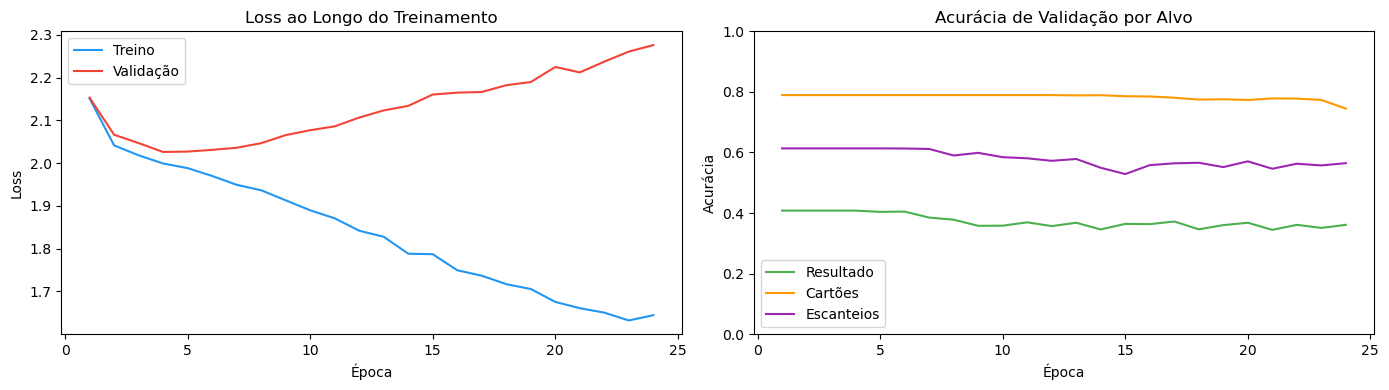

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep, history["train_loss"], label="Treino",    color="#2196F3")
axes[0].plot(ep, history["val_loss"],   label="Validação", color="#F44336")
axes[0].set_title("Loss ao Longo do Treinamento")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(ep, history["val_acc_r"], label="Resultado",  color="#4CAF50")
axes[1].plot(ep, history["val_acc_y"], label="Cartões",    color="#FF9800")
axes[1].plot(ep, history["val_acc_c"], label="Escanteios", color="#9C27B0")
axes[1].set_title("Acurácia de Validação por Alvo")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia"); axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout(); plt.show()


## 7. Avaliação Final

In [31]:
model.eval()
all_probs_r, all_probs_y, all_probs_c = [], [], []
all_true_r, all_true_y, all_true_c    = [], [], []
softmax = nn.Softmax(dim=1)

with torch.no_grad():
    for X_b, y_r, y_y, y_c in val_loader:
        X_b = X_b.to(DEVICE)
        lr, ly, lc = model(X_b)
        all_probs_r.append(softmax(lr).cpu().numpy())
        all_probs_y.append(softmax(ly).cpu().numpy())
        all_probs_c.append(softmax(lc).cpu().numpy())
        all_true_r.extend(y_r.numpy()); all_true_y.extend(y_y.numpy()); all_true_c.extend(y_c.numpy())

probs_r = np.vstack(all_probs_r); probs_y = np.vstack(all_probs_y); probs_c = np.vstack(all_probs_c)
true_r  = np.array(all_true_r);   true_y  = np.array(all_true_y);   true_c  = np.array(all_true_c)

preds_r = probs_r.argmax(1); preds_y = probs_y.argmax(1); preds_c = probs_c.argmax(1)

metrics = {
    "resultado": {
        "acurácia":  accuracy_score(true_r, preds_r),
        "log_loss":  log_loss(true_r, probs_r),
        "labels":    ["H","D","A"],
    },
    "cartões": {
        "acurácia":  accuracy_score(true_y, preds_y),
        "log_loss":  log_loss(true_y, probs_y),
        "labels":    ["Under 6.5","Over 6.5"],
    },
    "escanteios": {
        "acurácia":  accuracy_score(true_c, preds_c),
        "log_loss":  log_loss(true_c, probs_c),
        "labels":    ["Under 10.5","Over 10.5"],
    },
}

print("── Métricas no Conjunto de Validação ────────────────────────────")
print(f"{'Alvo':<14} {'Acurácia':>10} {'Log-loss':>10}")
print("─" * 38)
for alvo, m in metrics.items():
    print(f"{alvo:<14} {m['acurácia']:>10.4f} {m['log_loss']:>10.4f}")

print("\nBaseline aleatório — resultado: acurácia ≈ 0.333, log-loss ≈ 1.099")
print("Baseline aleatório — cartões/escanteios (binário): acurácia ≈ 0.500, log-loss ≈ 0.693")


── Métricas no Conjunto de Validação ────────────────────────────
Alvo             Acurácia   Log-loss
──────────────────────────────────────
resultado          0.4081     1.0875
cartões            0.7895     0.5117
escanteios         0.6135     0.6669

Baseline aleatório — resultado: acurácia ≈ 0.333, log-loss ≈ 1.099
Baseline aleatório — cartões/escanteios (binário): acurácia ≈ 0.500, log-loss ≈ 0.693


## 8. Calibration Plot

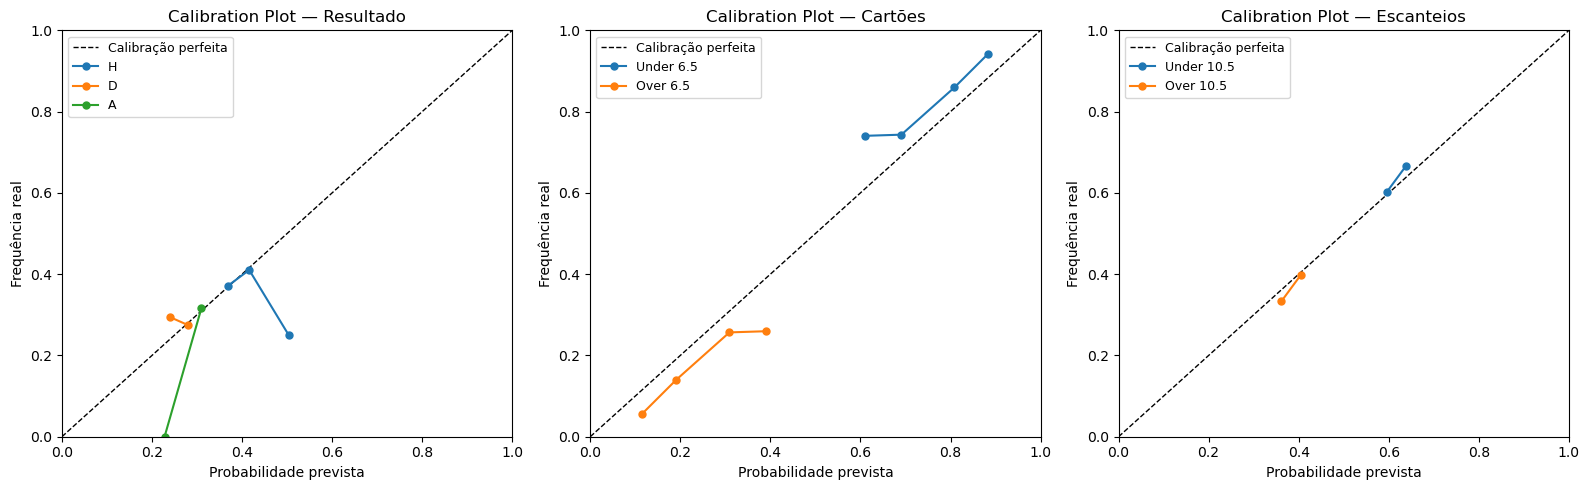

Quanto mais próxima a linha da diagonal, mais calibrado o modelo.


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, probs, truths, labels) in zip(axes, [
    ("Resultado",  probs_r, true_r, ["H","D","A"]),
    ("Cartões",    probs_y, true_y, ["Under 6.5",  "Over 6.5"]),
    ("Escanteios", probs_c, true_c, ["Under 10.5", "Over 10.5"]),
]):
    ax.plot([0,1],[0,1], "k--", lw=1, label="Calibração perfeita")
    for cls_idx, label in enumerate(labels):
        prob_true, prob_pred = calibration_curve(
            (truths == cls_idx).astype(int),
            probs[:, cls_idx],
            n_bins=8, strategy="uniform"
        )
        ax.plot(prob_pred, prob_true, "o-", ms=5, label=label)
    ax.set_title(f"Calibration Plot — {name}")
    ax.set_xlabel("Probabilidade prevista"); ax.set_ylabel("Frequência real")
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.tight_layout(); plt.show()
print("Quanto mais próxima a linha da diagonal, mais calibrado o modelo.")


## 9. Salvando o Modelo

In [33]:
WINDOW = 10

In [34]:
model_path = MODELS_DIR / "oscabet_nn_v1.pt"
meta_path  = MODELS_DIR / "oscabet_nn_v1_meta.json"

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim":        X_train.shape[1],
    "feat_cols":        feat_cols,
    "train_cutoff":     TRAIN_CUTOFF_DATE,
    "hyperparams": {
        "epochs": EPOCHS, "lr": LR, "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE, "window": WINDOW,
    },
    "metrics": {k: {m: float(v) for m, v in val.items() if isinstance(v, float)}
                for k, val in metrics.items()},
}, model_path)

with open(meta_path, "w") as f:
    json.dump({
        "input_dim": int(X_train.shape[1]),
        "feat_cols": feat_cols,
        "train_cutoff": TRAIN_CUTOFF_DATE,
        "n_train": int(len(X_train)),
        "n_val":   int(len(X_val)),
        "metrics": {k: {m: round(float(v), 4) for m, v in val.items() if isinstance(v, float)}
                    for k, val in metrics.items()},
    }, f, indent=2, ensure_ascii=False)

print(f"✅ Modelo salvo em: {model_path}")
print(f"✅ Metadados em:    {meta_path}")


✅ Modelo salvo em: /Users/ian/Desktop/programacao/oscabet_IA_Logica_1s/agent/models/oscabet_nn_v1.pt
✅ Metadados em:    /Users/ian/Desktop/programacao/oscabet_IA_Logica_1s/agent/models/oscabet_nn_v1_meta.json
